# Did LEVIATHAN filter the inversions?
So it doesn't seem like repeat-regions are too responsible for the false negatives (uncalled inversions). The next place to look is the `.candidates` files LEVIATHAN outputs. These files contain the list of all putatively called structural variants, which the program then filters based on some criteria to output the final called variant set. The question we're trying to address here is: **did LEVIATHAN identify the inversions initially and then filter them out?**

In [70]:
library(dplyr)
library(ggpattern)
library(ggplot2)
library(ggpubr)
library(tidyr)

## Processing the candidates
I think these data have to get processed similarly to how we did the matchy-matchy for the SVs leviathan ultimately called. It may be easier to load in the big table that process produced and add a boolean column to it that's essentially "did leviaithan initially catch this?"

In [5]:
assessed_inversions <- read.csv("assess_called_sv/linkedread.sv.assessment", header = T)
assessed_inversions$candidate <- FALSE
head(assessed_inversions)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end,technology,candidate
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<lgl>
1,2L,1,1,0.5,11,small,TRUE,hom,false negative,3193196,3214221,linkedread,FALSE
2,2L,1,1,2.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,FALSE
3,2L,1,1,5.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,FALSE
4,2L,1,1,10.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,FALSE
5,2L,1,1,20.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread,FALSE
6,2L,1,1,0.5,1,small,TRUE,hom,false negative,3193196,3214221,linkedread,FALSE


This is a simple function to generate the path and read in the leviathan candidates file we would be interested in parsing. It's here as a separate function to make the main processing loop less bloated and easier to read.

In [3]:
read_candidatefile <- function(.size, .depth, .sample) {
    if (.sample <= 10){
        .cand_file <- sprintf("simulated_data/called_sv/leviathan/%s/depth_%s/by_sample90/logs/leviathan/sample_%02d.candidates", .size, .depth, .sample)
    } else {
        .cand_file <- sprintf("simulated_data/called_sv/leviathan/%s/depth_%s/by_pop90/logs/leviathan/pop1.candidates", .size, .depth)
    }
    return (
        read.table(
            .cand_file,
            col.names = c("contig", "position_start", "position_end", "contig2", "position_start2", "position_end2", "barcodes")
        )
    )
}

Likewise a generic function to filter the table for the specific sample/depth/inversion-class

In [6]:
filter_assess <- function(data, .size, .depth, .sample) {
    return (
        filter(data, depth == as.double(.depth), size == .size, sample == .sample)
    )
}

In [47]:
sizes = c("small", "medium", "large", "xl")
depths = c("0.5", "2", "5", "10", "20")
assess_candidates <- assessed_inversions[0,]

for (.size in sizes) {
    for (.depth in depths) {
        for (.sample in 1:11) {
            .candidates <- read_candidatefile(.size, .depth, .sample)
            .assess <- filter_assess(assessed_inversions, .size, .depth, .sample)
            for (i in 1:nrow(.assess)) {
                query <- which(
                    .assess$contig[i] == .candidates$contig &
                    (
                        (.assess$position_start[i] >= .candidates$position_start & .assess$position_start[i] <=  .candidates$position_end) |
                        (.assess$position_start[i] >= .candidates$position_start2 & .assess$position_start[i] <= .candidates$position_end2)
                    )
                )
                if(length(query) > 0){
                    .assess$candidate[i] <- TRUE
                }
            }
            assess_candidates <- rbind(assess_candidates, .assess)
        }
    }
}

In [49]:
sum(assess_candidates$candidate)
head(assess_candidates[assess_candidates$candidate,])

[1] 1596

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end,technology,candidate
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<lgl>
1,2L,1,1,0.5,1,small,TRUE,hom,false negative,3193196,3214221,linkedread,TRUE
52,3L,2,9,0.5,3,small,FALSE,NA,true negative,14492093,14496538,linkedread,TRUE
65,2L,5,14,0.5,4,small,TRUE,hom,false negative,20107901,20113695,linkedread,TRUE
78,3R,3,16,0.5,4,small,TRUE,hom,false negative,22829883,22851519,linkedread,TRUE
81,2L,1,1,0.5,5,small,TRUE,hom,false negative,3193196,3214221,linkedread,TRUE
87,2R,2,5,0.5,5,small,TRUE,het,false negative,9952840,9959287,linkedread,TRUE


In [50]:
write.table(assess_candidates, file = "inversions_candidates.assessment", quote = F, row.names = F)

So, there are `1596` instances where an inversion appeared as an SV candidate. The next step would be to explore the characteristics of these candidates:
- are they false positives
- are they still false negatives
- make some plots highlighting some possible trends


In [66]:
assess_candidates$assessment_cand <- ""
assess_candidates$call_status <- assess_candidates$assessment 

for (i in 1:nrow(assess_candidates)) {
    if (assess_candidates$simulated[i]){
        .status <- ifelse(assess_candidates$candidate[i], "true positive", "false negative")
    } else {
        .status <- ifelse(assess_candidates$candidate[i], "false positive", "true negative")
    }
    assess_candidates$assessment_cand[i] <- .status

    if (assess_candidates$assessment[i] == "false negative"){
        assess_candidates$call_status[i] <- ifelse(.status == "true positive", "filtered out", "never called")
    }
 }

head(assess_candidates)
table(assess_candidates$assessment_cand)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end,technology,candidate,assessment_cand,call_status
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>,<chr>
1,2L,1,1,0.5,1,small,TRUE,hom,false negative,3193196,3214221,linkedread,TRUE,true positive,filtered out
2,2L,2,2,0.5,1,small,TRUE,hom,false negative,3940211,3944863,linkedread,FALSE,false negative,never called
3,2L,3,8,0.5,1,small,TRUE,hom,false negative,13024404,13026577,linkedread,FALSE,false negative,never called
4,2L,4,10,0.5,1,small,TRUE,hom,false negative,14845709,14861200,linkedread,FALSE,false negative,never called
5,2L,5,14,0.5,1,small,TRUE,hom,false negative,20107901,20113695,linkedread,FALSE,false negative,never called
6,2R,1,4,0.5,1,small,TRUE,het,false negative,4328632,4333509,linkedread,FALSE,false negative,never called



false negative false positive  true negative  true positive 
           682            288            362           1308 

## Single-Sample Detection
Okay cool, but which inversions were detected by leviathan and ultimately filtered out? Let's create that same heatmap from the inversion detection notebook, but this time split `false negative` into one of `never called` and `filtered out`.

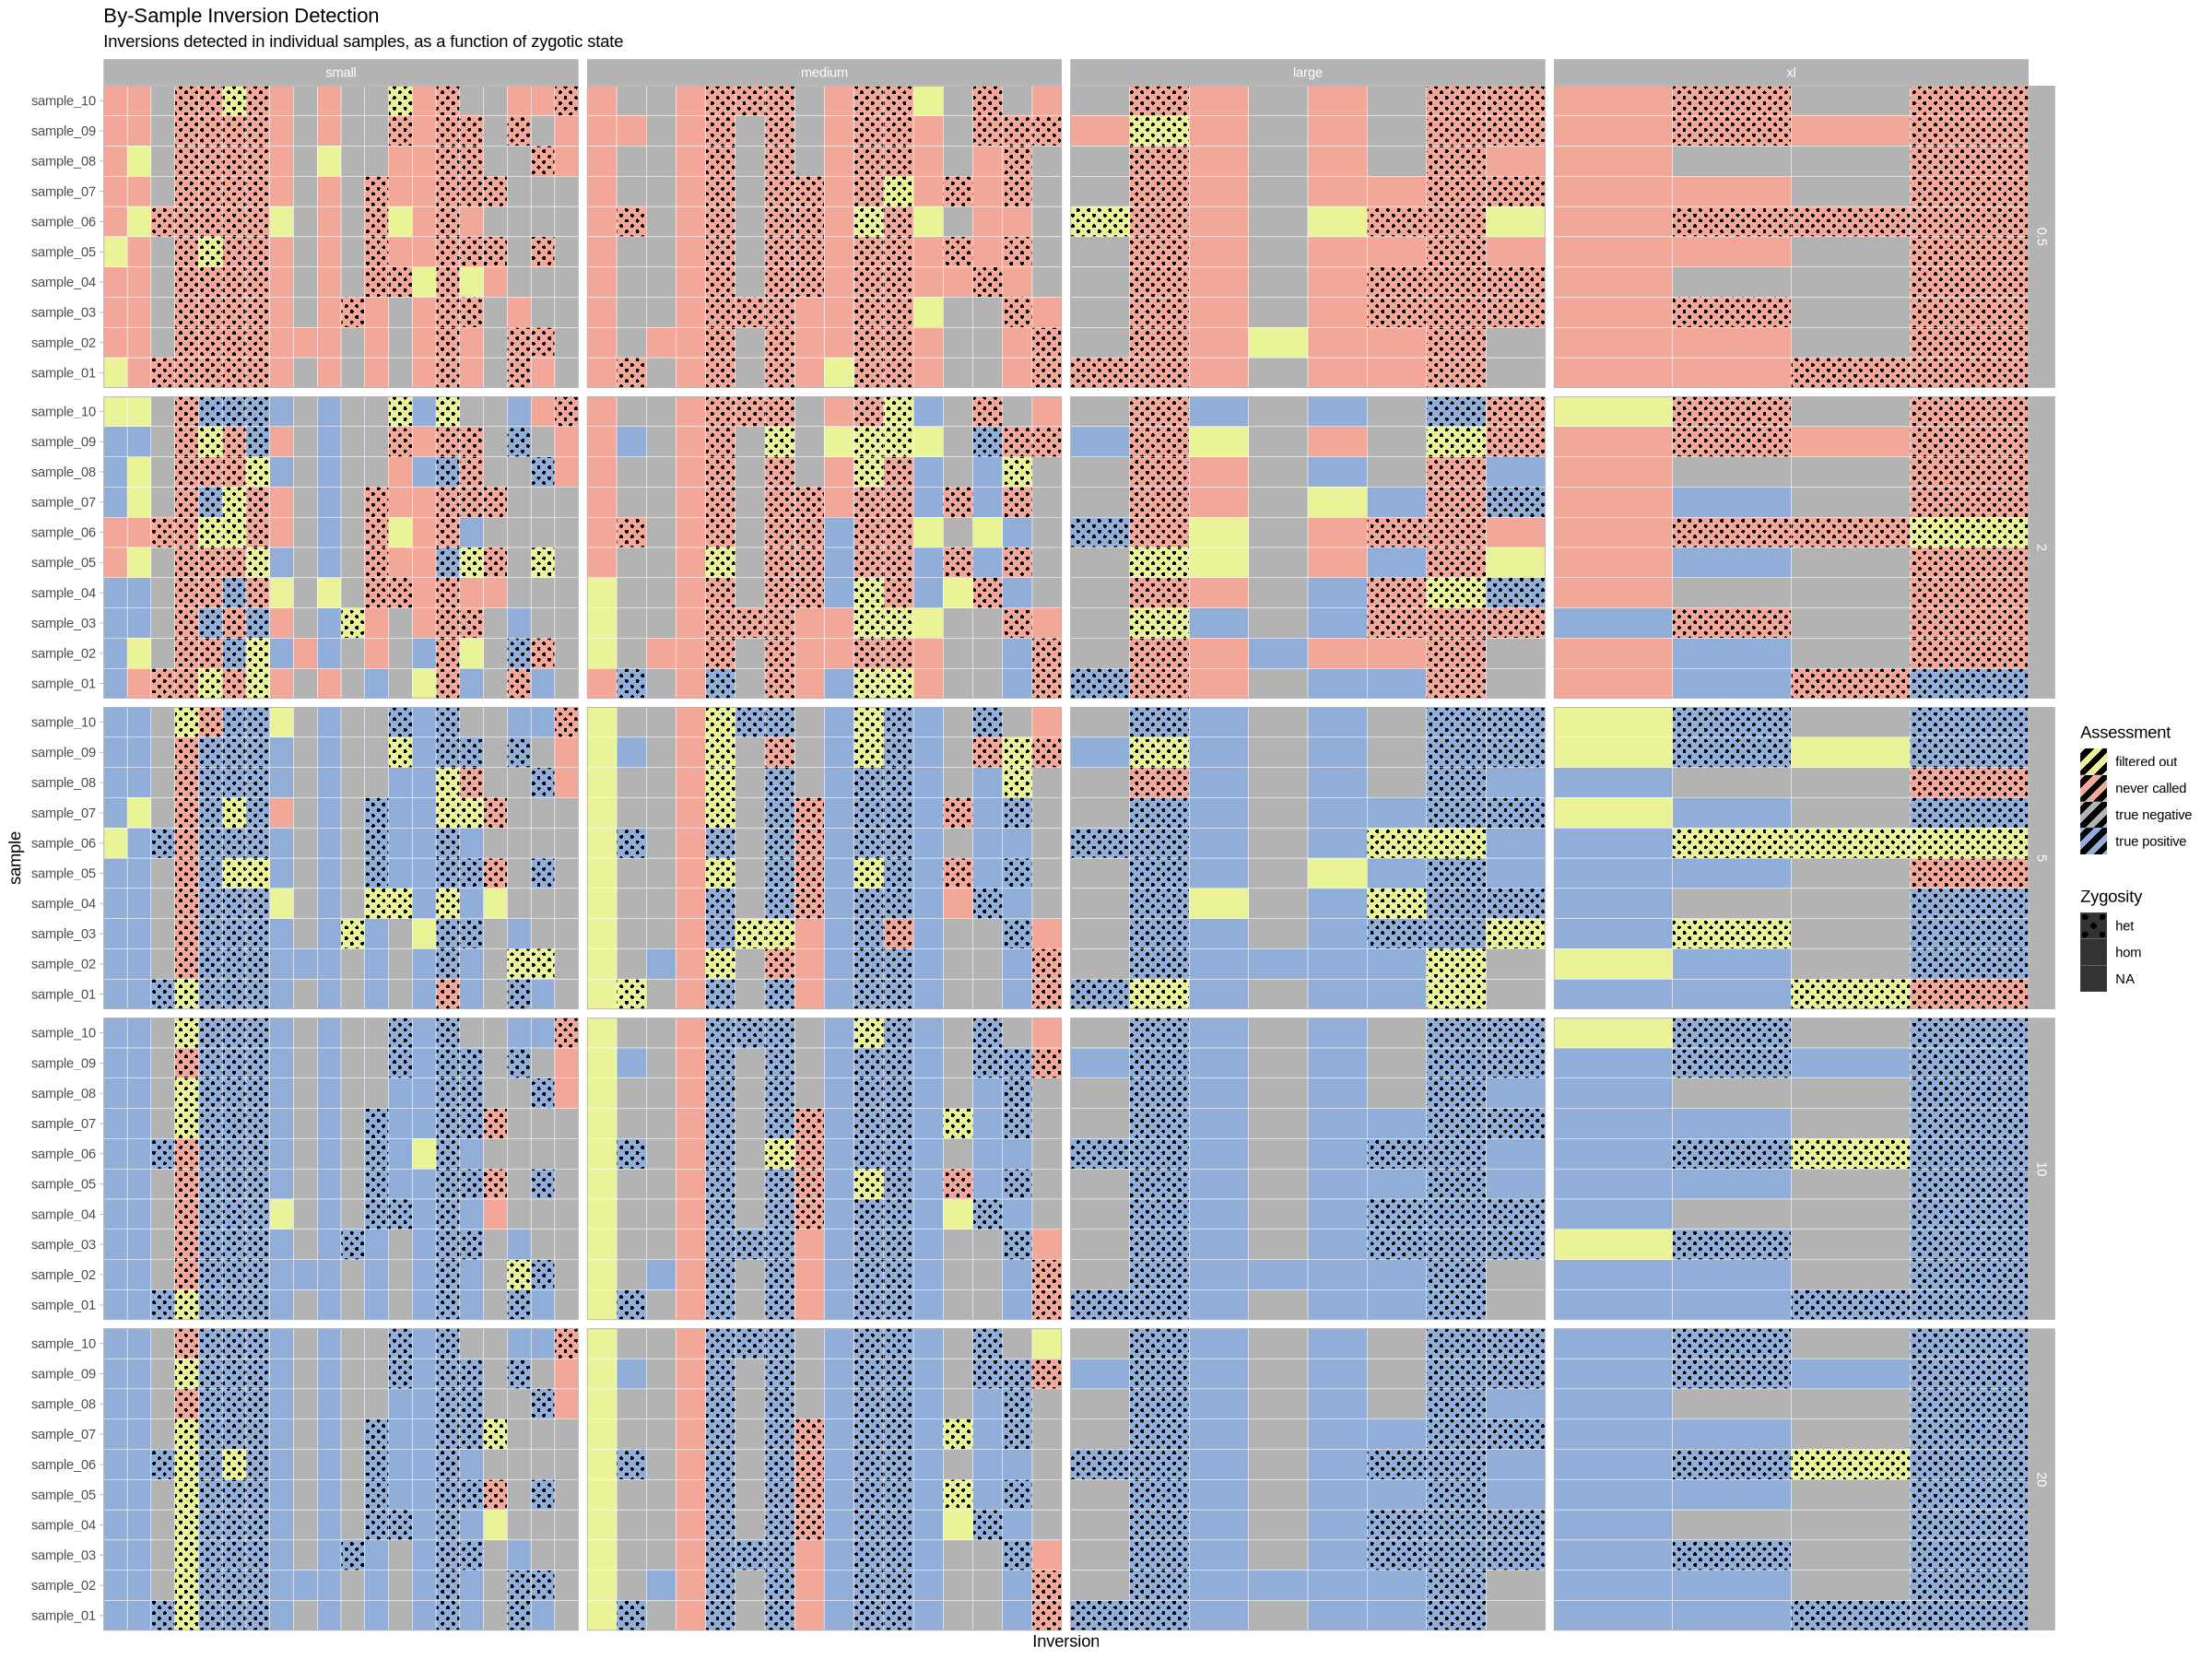

In [76]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 15)
axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
assess_candidates[assess_candidates$sample != 11,] %>%
    ggplot(aes(y = sample, x = id, fill = call_status, pattern = zygosity)) +
        geom_tile_pattern(
            pattern_color = NA,
            color = "white",
            pattern_fill = "black",
            pattern_angle = 45,
            pattern_density = 0.5,
            pattern_spacing = 0.025,
            pattern_key_scale_factor = 1
        ) +
        theme_light() +
        labs(
            title = "By-Sample Inversion Detection",
            subtitle = "Inversions detected in individual samples, as a function of zygotic state",
            fill = "Assessment",
            pattern = "Zygosity"
        ) +
        scale_fill_manual(values = c("never called" = "#f3a798ff", "filtered out" = "#eaf398ff", "true negative" = "grey70", "true positive" = "#90aed8")) +
        scale_pattern_manual(values = c("het" = "circle", "hom" = "none")) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        coord_cartesian(expand = F) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(depth ~ factor(size, levels = c("small", "medium", "large", "xl")), scales = "free_x")

## Pooled Sample Detection
Same idea, but for the pooled samples.

In [74]:
plot_pools_matrix <- function(data, size_treatment){
    .data <- data[data$sample == 11 & data$size == size_treatment,]
    .data$contig <- gsub("2L", "2L (all homozygous)", .data$contig)
    .data$contig <- gsub("2R", "2R (all heterozygous)", .data$contig)
    .data$contig <- gsub("3L", "3L (inversions common)", .data$contig)
    .data$contig <- gsub("3R", "3R (inversions rare)", .data$contig)
 
    ggplot(.data, aes(y = 1, x = inversion, fill = call_status)) +
        geom_tile(color = "white", linewidth = 1.5) +
        theme_light() +
        scale_fill_manual(values = c("never called" = "#f3a798ff", "filtered out" = "#eaf398ff", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "Assessment") +
        labs(fill = "Assessment") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        ) +
        coord_cartesian(expand = F) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

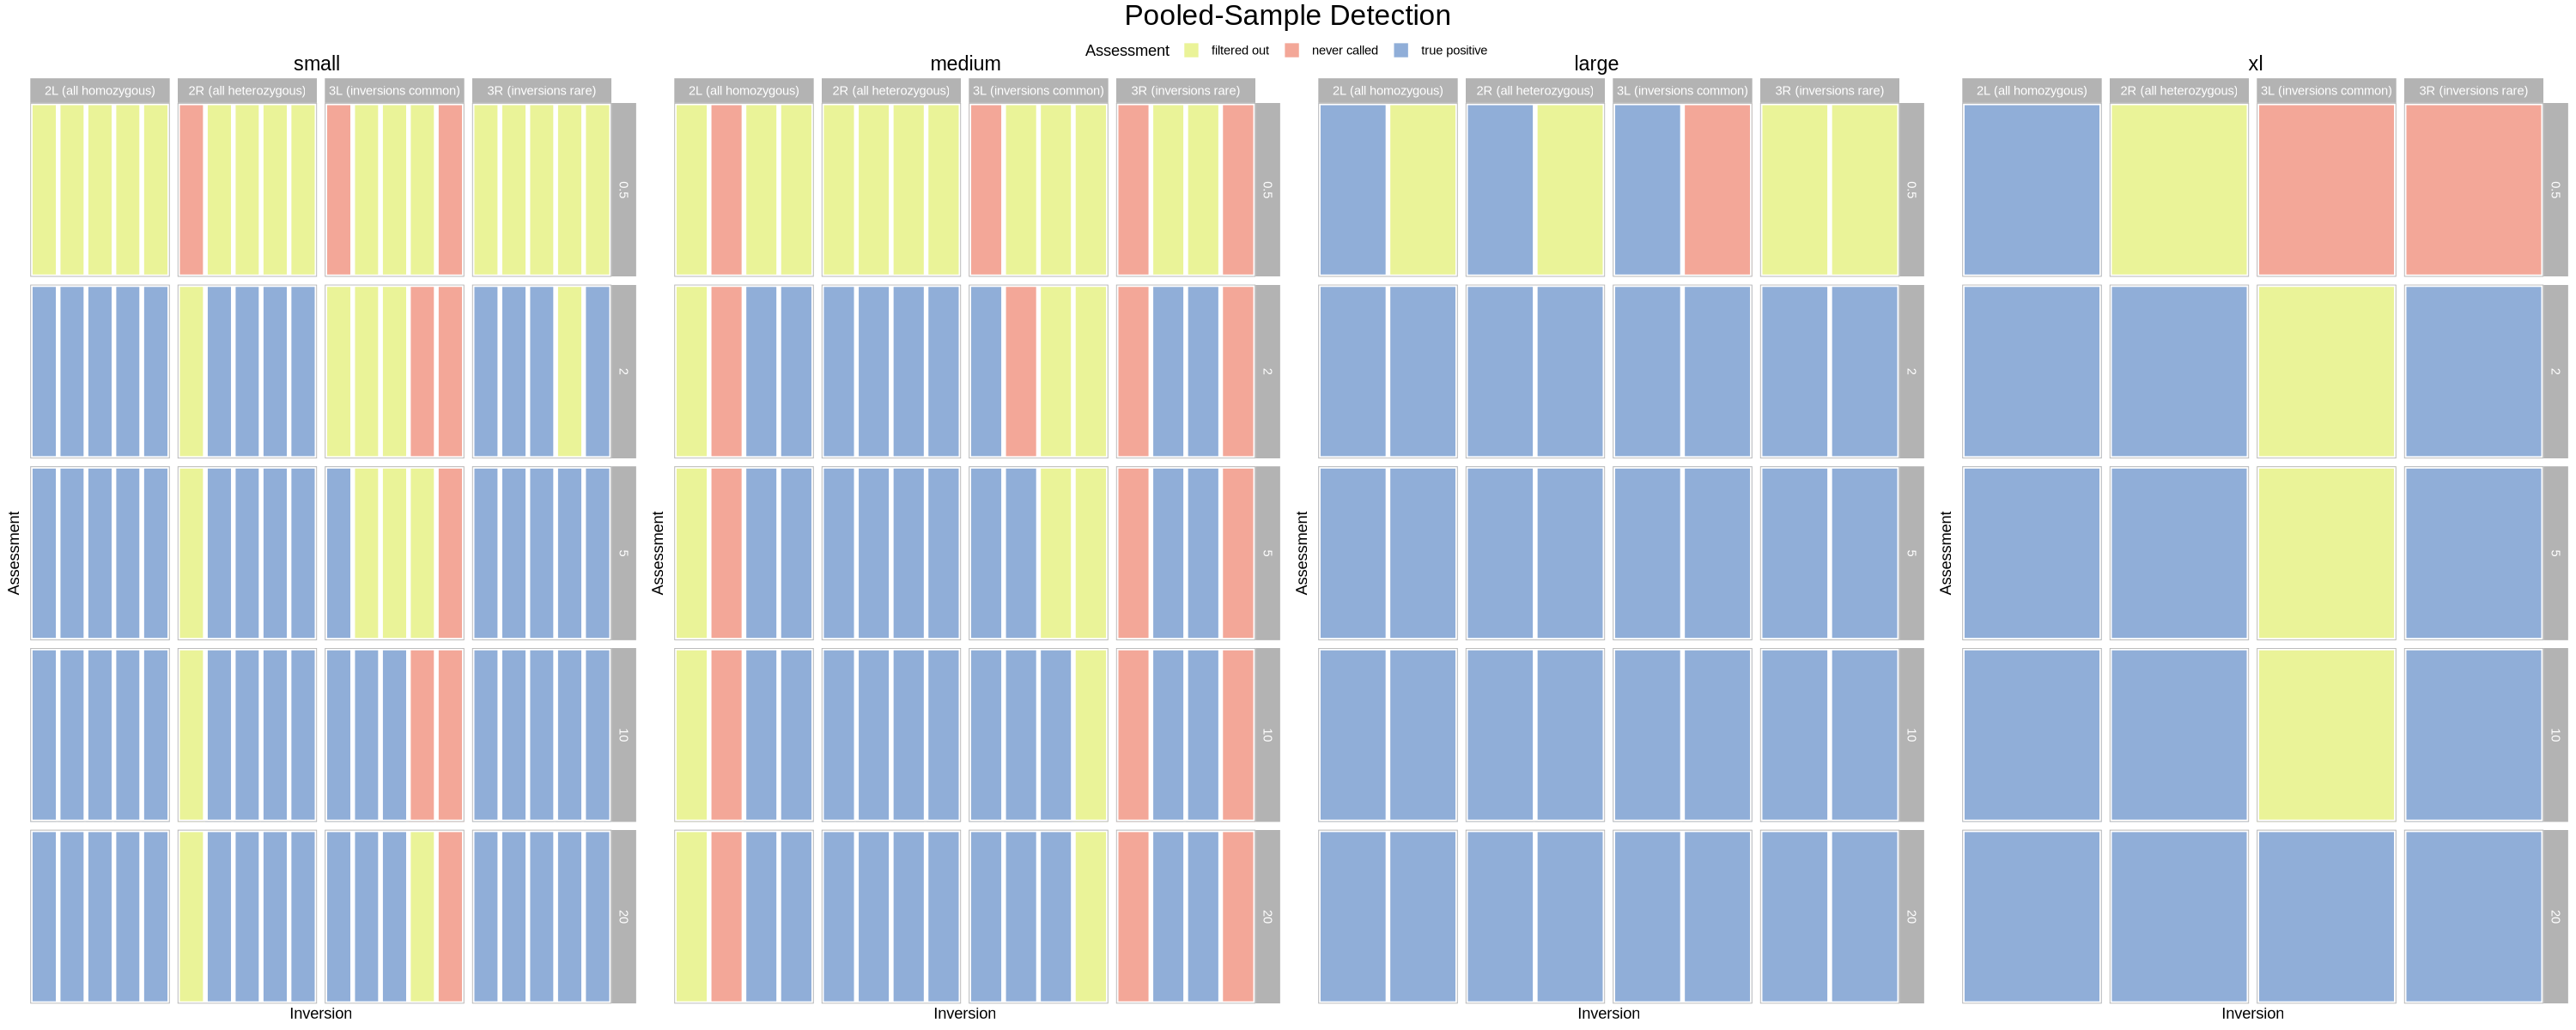

In [ ]:
options(warn = -1, repr.plot.width = 25, repr.plot.height = 10)
plot <- ggarrange(
    plot_pools_matrix(assess_candidates, "small"),
    plot_pools_matrix(assess_candidates, "medium"),
    plot_pools_matrix(assess_candidates, "large"),
    plot_pools_matrix(assess_candidates, "xl"),
    labels = c("small", "medium", "large", "xl"),
    nrow = 1, ncol = 4, common.legend = T, font.label = c(face = "plain"), legend = "top", vjust = 0, label.x = c(0.42, 0.39, 0.41, 0.48)
)
annotate_figure(
    plot,
    top = text_grob(
        "Pooled-Sample Detection", color = "black", size = 20
    )
)